<a href="https://colab.research.google.com/github/JonathanA214/Study_guide/blob/main/Copy_of_CPSC483_HW2_wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPSC 483 Homework 2

---
In this homework assignment, you'll explore the wine quality dataset from the UCI Machine Learning Repository.

**LIST COLLABORATORS HERE** (double click a text block to edit it):

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Scikit-Learn ≥1.0.1 is required:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Let's define the default font sizes, to plot pretty figures:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Please choose a different random seed - feel free to match the seed with your collaborators to see if you get similar results.

In [4]:
import numpy as np
import pandas as pd
import time

seed = 10 # Change this to your favorite number
np.random.seed(seed)

We'll need to install the package first that allows you to download datasets from the UCI ML Repo through the `ucimlrepo` package, which is not pre-installed in Google Colab. You can do command line inputs by putting an exclamation point before your code line to install this package.

In [5]:
!pip install ucimlrepo

We will be working with the [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) dataset, where the aim is to predict a wine's quality score (out of 10) based on its attributes.

I am providing you with the code to download the dataset, formatting it into a Pandas DataFrame, and doing some mild preprocessing, so there's nothing to change in this block (unless you want to - then knock yourself out!). But take a look to make sure you understand how I'm dealing with the data.

In [6]:
from ucimlrepo import fetch_ucirepo
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# fetch dataset
wine = fetch_ucirepo(id=186)

# data (as pandas dataframes)
wine_df = wine.data.original

# Transform the color column to a binary is_red column for simplicity
wine_df.color = (wine_df.color == 'red').astype(int)
wine_df = wine_df.rename(columns = {'color': 'is_red'})

# Create a Test Set
train, test = train_test_split(wine_df, test_size=0.2, random_state=seed)

# Separate out the labels
wine_train = train.drop("quality", axis=1)
wine_train_labels = train['quality'].copy()

# Create preprocessing pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
color_pipeline = make_pipeline(SimpleImputer(strategy="median"))
num_columns = wine_train.columns.drop("is_red")
preprocessing = ColumnTransformer([
    ("num_features", num_pipeline, num_columns),
    ("color", color_pipeline, ["is_red"])
])

# Peak at our preprocessed data
wine_processed = preprocessing.fit_transform(wine_train)
wine_processed_df = pd.DataFrame(
    wine_processed,
    columns=preprocessing.get_feature_names_out(),
    index=wine_train.index)
wine_processed_df.head()

,num_features__fixed_acidity,num_features__volatile_acidity,num_features__citric_acid,num_features__residual_sugar,num_features__chlorides,num_features__free_sulfur_dioxide,num_features__total_sulfur_dioxide,num_features__density,num_features__pH,num_features__sulphates,num_features__alcohol,color__is_red
2705,-1.543902,-0.601460,0.898514,-0.349654,-0.829812,-0.544608,0.206372,-0.901979,2.057086,-0.274586,0.597472,0.0
2120,0.526591,-0.907729,-0.406451,-0.707385,-0.486077,-1.270297,0.470240,-0.172489,-1.046699,1.403002,-0.573928,0.0
2145,-0.700368,-0.478952,-0.543816,0.365806,-0.486077,0.404370,0.980384,0.358050,1.684632,0.731967,-0.657600,0.0
2756,0.449906,-0.233936,-0.200404,2.396451,-0.056407,-0.432963,0.329511,1.684396,-0.363866,-1.012725,-1.243300,0.0
398,3.287249,1.542426,1.860066,-0.602170,0.888865,-0.991186,-1.183331,1.352809,-0.239715,0.799070,0.430129,1.0


# Part 1 - Creating Custom Linear Regression Solvers

We discussed in class how scikit-learn only supports two ways to fit a linear regression model. In this task, you will implement the other three methods mentioned in class to fit linear regression models by creating custom classes.

## Exercise 1 - Using the Normal Equations

Use NumPy's matrix manipulation library for **ridge** regression using the normal equations.

Remember to include a bias column in the 0th column by making a copy of the original `X` and adding the column to `X`. The functions `np.ones`, `np.hstack`, and `np.eye` may be helpful for your implementation (see the NumPy docs). Also note that `@` is for matrix multiplication, while `*` is element-wise multiplication / dot product!


In [7]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split

class LinearRegressionNormalEquation(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0):
        self.theta_ = None # This is your model parameters to learn
        self.alpha = alpha # For ridge regression

    def fit(self, X, y):
        # Types should be NumPy arrays
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        m, n = X.shape

        # Put your normal equation process here!
        X_b = np.hstack([np.ones((m, 1)), X.copy()])

        # Ridge penalty matrix; the bias term (0th entry) is not regularized
        A = np.eye(n + 1)
        A[0, 0] = 0

        # theta = (X^T X + alpha * A)^-1 X^T y
        theta = np.linalg.solve(X_b.T @ X_b + self.alpha * A, X_b.T @ y)

        # Save your learned theta_ value
        self.theta_ = theta

        return self

    def predict(self, X):
        # Put how you predict with the learned self.theta_ here
        X = np.asarray(X, dtype=float)
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])

        return X_b @ self.theta_ # Should return an np.ndarray of predictions

You should then be able to run the following code if the above is implemented properly, which runs a 5-fold cross validation to compute the $R^2$, along with the runtime needed to do cross validation (don't worry about the actual $R^2$ value yet. To check your work, you should have an average $R^2$ somewhere between 0.2 and 0.4).

In [8]:
from sklearn.model_selection import cross_val_score

start_time = time.perf_counter()

normaleq = make_pipeline(preprocessing, LinearRegressionNormalEquation(alpha = 0.001))

normal_r2 = cross_val_score(normaleq, wine_train, wine_train_labels,
                              scoring="r2", cv=5)

end_time = time.perf_counter()
runtime_normaleq = end_time - start_time
pd.Series(normal_r2).describe()

count    5.000000
mean     0.290602
std      0.030757
min      0.260718
25%      0.267201
50%      0.291166
75%      0.295130
max      0.338796
dtype: float64

## Exercise 2 - Batch Gradient Descent

Implement batch gradient descent for **elastic-net** regression. Have the stopping criterion be when $\Vert g(\boldsymbol \theta)\Vert < 0.0001$ **or** at 1000 epochs, whichever comes first.

Note that you may get odd results - one possible reason may be due to the learning rate. Try playing around with the learning rate - I have set it to 0.01 but see what works.

*Hint*: Some useful functions here may include `np.sign` for finding the sign of an array and `np.zeros` for initializing an array of zeros.

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split

class LinearRegressionBatchGD(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0, r=0.15, learning_rate=0.1):
        self.theta_ = None # This is your model parameters to learn
        self.alpha = alpha
        self.r = r # The balance between the two estimators
        self.learning_rate = learning_rate # eta

    def fit(self, X, y):
        # Type Check
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        m, n = X.shape

        # Put your batch gradient descent process here!
        X_b = np.hstack([np.ones((m, 1)), X.copy()])
        theta = np.zeros(n + 1)

        for epoch in range(1000):
            # Gradient of the MSE over the full training set
            gradient = 2 / m * X_b.T @ (X_b @ theta - y)

            # Elastic-net subgradient: 2*r*alpha*sign(theta) + 2*(1 - r)*alpha/m * theta
            # (the bias term theta[0] is not regularized)
            penalty = 2 * self.r * self.alpha * np.sign(theta) + 2 * (1 - self.r) * self.alpha / m * theta
            penalty[0] = 0
            gradient += penalty

            if np.linalg.norm(gradient) < 0.0001:
                break

            theta = theta - self.learning_rate * gradient

        # Save your learned theta_ value
        self.theta_ = theta

        return self

    def predict(self, X):
        # Put how you predict with the learned self.theta_ here
        # Should be the same as before
        X = np.asarray(X, dtype=float)
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])

        return X_b @ self.theta_ # Should return an np.ndarray of predictions

You should then be able to run the following code if the above is implemented properly, which runs a 5-fold cross validation to compute the $R^2$, along with the runtime needed to do cross validation. Note that the results should be similar (but not necessarily the exact same) between exercises 1 and 2.

In [10]:
start_time = time.perf_counter()

batch = make_pipeline(preprocessing, LinearRegressionBatchGD(alpha = 0.001))

batch_r2 = cross_val_score(batch, wine_train, wine_train_labels,
                              scoring="r2", cv=5)

end_time = time.perf_counter()
runtime_batch = end_time - start_time
pd.Series(batch_r2).describe()

count    5.000000
mean     0.290604
std      0.030789
min      0.260519
25%      0.267242
50%      0.291299
75%      0.295196
max      0.338764
dtype: float64

## Exercise 3 - Mini-batch Gradient Descent

You should now adapt the code you already wrote in Exercise 2 to do mini-batch gradient descent. Use a batch size of 64 (i.e., 64 instances per batch). Feel free to change this though - the typical standard in machine learning is to set a batch size equal to powers of 2.

Ensure that your X and y values are shuffled together so that the labels stay with their corresponding instances. One way to do this is to shuffle indexes instead of the instances themselves using NumPy:

- First, initialize your `rng`
    ```
    rng = np.random.default_rng(seed=seed)
    ```
- Then, for each epoch, you run
    ```
    indices = rng.permutation(m) # m is the number of instances
    ```

Ensure that you are using a learning schedule to stabilize your subgradient steps over iterations and epochs. A common learning schedule is to start with initial parameters $\eta_0$ and $\eta_1$, and have the schedule
$$\eta = \frac{\eta_0}{iteration + \eta_1}$$
where $iteration$ refers to each minibatch update to $\boldsymbol \theta$.

Lastly, instead of stopping at certain magnitudes of the gradient (which we don't have the entirety of in mini-batch gradient descent), stop if the magnitude of the difference between the old $\boldsymbol \theta$ and new $\boldsymbol \theta$ is less than 0.0001 at the **end** of each epoch or if 1000 epochs have passed.

**Note**: Your implementation may be slower than `SGDRegressor` in scikit-learn, even for a batch size of 1 (which is the same as stochastic gradient descent). This is because scikit-learn has its own optimization strategies to make stochastic gradient descent faster, so don't sweat if your implementation is slower. But, your implementation should still be close to the optimal value of $\boldsymbol \theta$.

In [11]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split

class LinearRegressionMiniBatchGD(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0, r=0.15, batch_size=64, epochs=1000, eta0=5, eta1=50):
        self.theta_ = None # This is your model parameters to learn
        self.alpha = alpha
        self.r = r # The balance between the two estimators
        self.eta0 = eta0
        self.eta1 = eta1
        self.batch_size = batch_size
        self.epochs = epochs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        m, n = X.shape

        # Put your mini-batch gradient descent algorithm here!
        X_b = np.hstack([np.ones((m, 1)), X.copy()])
        theta = np.zeros(n + 1)
        rng = np.random.default_rng(seed=seed)
        iteration = 0

        for epoch in range(self.epochs):
            theta_old = theta.copy()
            indices = rng.permutation(m) # shuffle X and y together

            for start in range(0, m, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X_b[batch_idx]
                y_batch = y[batch_idx]
                batch_m = len(batch_idx)

                gradient = 2 / batch_m * X_batch.T @ (X_batch @ theta - y_batch)
                # m (not batch_m) in the ridge term: it comes from the full cost J(theta)
                penalty = 2 * self.r * self.alpha * np.sign(theta) + 2 * (1 - self.r) * self.alpha / m * theta
                penalty[0] = 0
                gradient += penalty

                # Learning schedule: eta = eta0 / (iteration + eta1)
                eta = self.eta0 / (iteration + self.eta1)
                theta = theta - eta * gradient
                iteration += 1

            if np.linalg.norm(theta - theta_old) < 0.0001:
                break

        # Save your learned theta_ value
        self.theta_ = theta

        return self

    def predict(self, X):
        # Put how you predict with the learned self.theta_ here
        # Should be the same as before
        X = np.asarray(X, dtype=float)
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])

        return X_b @ self.theta_ # Should return an np.ndarray of predictions

Again, you should check your implementation with the following code.

In [12]:
start_time = time.perf_counter()

minibatch = make_pipeline(preprocessing, LinearRegressionMiniBatchGD(alpha = 0.001))

minibatch_r2 = cross_val_score(minibatch, wine_train, wine_train_labels,
                              scoring="r2", cv=5)

end_time = time.perf_counter()
runtime_minibatch = end_time - start_time
pd.Series(minibatch_r2).describe()

count    5.000000
mean     0.289566
std      0.031553
min      0.256027
25%      0.267134
50%      0.293037
75%      0.293860
max      0.337774
dtype: float64

## Exercise 4 - Tuning a Linear Regression Solver Method

I have implemented `Ridge()` and `SGDRegressor()` to see the performance of the singular value decomposition and stochastic gradient descent methods for solving linear regression, and you can now compare the runtimes of each method on the wine quality dataset.

In [13]:
from sklearn.linear_model import Ridge, SGDRegressor

# SVD with Ridge Regression
start_time = time.perf_counter()

svd = make_pipeline(preprocessing, Ridge(alpha = 0.0001, solver="svd"))
svd_r2 = cross_val_score(svd, wine_train, wine_train_labels,
                              scoring="r2", cv=5)
end_time = time.perf_counter()
runtime_svd = end_time - start_time

# SGD for ElasticNet Regression
start_time = time.perf_counter()

sgd = make_pipeline(preprocessing, SGDRegressor(penalty = "elasticnet", alpha = 0.001, l1_ratio = 0.15))
sgd_r2 = cross_val_score(sgd, wine_train, wine_train_labels,
                              scoring="r2", cv=5)
end_time = time.perf_counter()
runtime_sgd = end_time - start_time

Prints out a summary of all their runtimes on 5-fold cross validation. Remember: each method's computational efficiency isn't the only factor to consider - ensure that you choose the right method by considering all benefits/drawbacks of each.

In [14]:
print("Runtimes for 5-fold cross validation")
print("Normal Equations: ", runtime_normaleq)
print("SVD: ", runtime_svd)
print("Batch Gradient Descent: ", runtime_batch)
print("Stochastic Gradient Descent: ", runtime_sgd)
print("Minibatch Gradient Descent: ", runtime_minibatch)

Runtimes for 5-fold cross validation
Normal Equations:  0.05894044100023166
SVD:  0.06479699000010442
Batch Gradient Descent:  0.2358971379999275
Stochastic Gradient Descent:  0.07351237900002161
Minibatch Gradient Descent:  1.0953438030001053


Based on your knowledge of each method and what you see in the time efficiency of each method, make an informed choice of which solving method you want to use.

Here, use your chosen solver method to determine if you are overfitting or underfitting, which you can do with the information from the following code bit (change `mysolver` to your chosen solver).

In [15]:
from sklearn.metrics import r2_score

# SVD: about as fast as the normal equations, but numerically stable when features
# are correlated (e.g. density vs. alcohol/sugar), needs no learning rate tuning,
# and gives the exact solution. The dataset is small enough that the gradient
# descent methods' scalability benefits don't matter here.
mysolver = make_pipeline(preprocessing, Ridge(alpha = 0.0001, solver="svd")) # Set this equal to whatever solve method you choose

mysolver.fit(wine_train, wine_train_labels)
mysolver.score(wine_train, wine_train_labels) # This prints out the training R^2

0.29788570471387843

Do the following:
* Determine if the $R^2$ error is due to overfitting or underfitting
* Take the correct course of action based on your knowledge by either making [polynomial features](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) and increasing regularization parameters.

Use `GridSearchCV` to tune all of the hyperparameters of your model. You should consider whether the vanilla Linear Regression model is overfitting or underfitting to help you choose which hyperparameters to search.

Try to get your cross-validation $R^2$ to improve from your grid search. You will likely need to create a new pipeline to do this.

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Insert your grid search here!
# The training R^2 (~0.3) is about the same as the cross-validation R^2, so the
# model is underfitting: add polynomial features to give it more capacity, and
# tune the ridge regularization to keep the extra features from overfitting.
poly_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(solver="svd")),
])

param_grid = {
    "poly__degree": [1, 2, 3],
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000],
}

grid_search = GridSearchCV(poly_pipeline, param_grid, cv=5, scoring="r2")
grid_search.fit(wine_train, wine_train_labels)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R^2:", grid_search.best_score_)
print("Baseline cross-validation R^2 (SVD, no polynomial features):", svd_r2.mean())

Best parameters: {'poly__degree': 2, 'ridge__alpha': 100}
Best cross-validation R^2: 0.3254610720814238
Baseline cross-validation R^2 (SVD, no polynomial features): 0.29060212676565855


At the top of the next bit of code, set the first variable to your best estimator from grid search and find out how well you do in testing once you're satisfied.

*Note*: You may have only seen a modest improvement in $R^2$ (around the order of 0.01-0.1), and that's okay! It may be that linear/polynomial regression is not the best model after all for this particular dataset and/or the features are not predictive, which is quite possible since this dataset has not been well explored like some others we've seen so far. As a machine learning engineer, at this stage you may have had to go back and investigating your data a bit more.

In [17]:
from sklearn.metrics import r2_score

# Insert your best estimator here!
final_model = grid_search.best_estimator_

wine_test = test.drop("quality", axis=1)
wine_test_labels = test['quality'].copy()

final_predictions = final_model.predict(wine_test)

final_r2 = r2_score(wine_test_labels, final_predictions)
final_r2

0.3435262254572833

# Part 2 - Classification Metrics with Logistic Regression

We will be using the same dataset, but now changing the target label. We will now use this dataset to predict whether an instance is red or white wine.

Like before, I'll provide you with the data preprocessing here.

In [18]:
# Separate out the columns
wine_train = train.drop("is_red", axis=1)
wine_train_labels = train['is_red'].copy()

# All features are numeric now, so the preprocessing is a bit simpler
preprocessing = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
wine_processed = preprocessing.fit_transform(wine_train)
wine_processed_df = pd.DataFrame(
    wine_processed,
    columns=preprocessing.get_feature_names_out(),
    index=wine_train.index)
wine_processed_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
2705,-1.543902,-0.601460,0.898514,-0.349654,-0.829812,-0.544608,0.206372,-0.901979,2.057086,-0.274586,0.597472,2.529691
2120,0.526591,-0.907729,-0.406451,-0.707385,-0.486077,-1.270297,0.470240,-0.172489,-1.046699,1.403002,-0.573928,-0.941565
2145,-0.700368,-0.478952,-0.543816,0.365806,-0.486077,0.404370,0.980384,0.358050,1.684632,0.731967,-0.657600,0.215520
2756,0.449906,-0.233936,-0.200404,2.396451,-0.056407,-0.432963,0.329511,1.684396,-0.363866,-1.012725,-1.243300,0.215520
398,3.287249,1.542426,1.860066,-0.602170,0.888865,-0.991186,-1.183331,1.352809,-0.239715,0.799070,0.430129,0.215520


## Exercise 5 - Plotting Precision and Recall

We will explore first-hand how to visualize the precision-recall curve on this dataset.

You should use scikit-learn's `LogisticRegression` class as well as the `precision_recall_curve` function in your implementation. The output should be the precision recall curve based on your **training data**.

Read the documentation on both to learn how to use them properly (you do not need to adjust any default parameters for this exercise if you don't want to, but feel free to!)

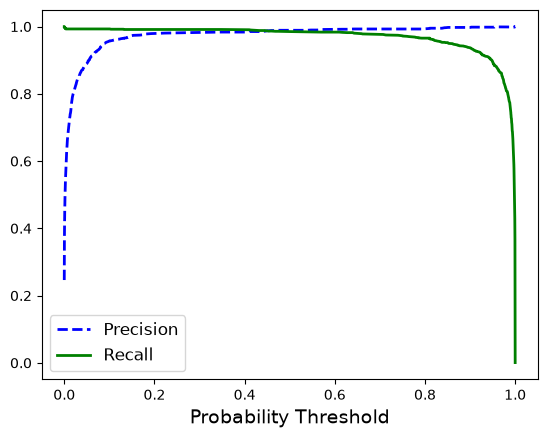

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Train your logistic regression model
log_reg = make_pipeline(preprocessing, LogisticRegression())
log_reg.fit(wine_train, wine_train_labels)

# Get the precisions, recalls, and thresholds from precision_recall_curve
y_probas = log_reg.predict_proba(wine_train)[:, 1] # probability of being red
precisions, recalls, thresholds = precision_recall_curve(wine_train_labels, y_probas)

# Once you have your precisions, recalls, and thresholds, you can use this bit of code
# to plot the precision and recall against thresholds
plt.plot(thresholds,precisions[:-1],"b--",label="Precision",linewidth=2)
plt.plot(thresholds,recalls[:-1],"g-",label="Recall",linewidth=2)
plt.xlabel("Probability Threshold")
plt.legend()
plt.show()

Although we are doing very well already (if all was implemented correctly), how can we hope to get the best $F_1$ score? The plot above should give you a hint of how to do this. (Answer in the text block below - which you can edit by double clicking it)

**Your Answer**: The $F_1$ score is the harmonic mean of precision and recall, so it is highest where the two are balanced, i.e. roughly where the precision and recall curves cross. Instead of using the default probability threshold of 0.5, we should pick the threshold that maximizes $F_1$. We can find it by computing $F_1 = \frac{2PR}{P + R}$ for every (precision, recall, threshold) triple returned by `precision_recall_curve` and taking the argmax. In the plot, the curves cross slightly below 0.5. On my training data, the best threshold is about 0.41 ($F_1 \approx 0.988$) compared to $F_1 \approx 0.987$ at 0.5. Ideally this threshold should be picked from cross-validated predictions (e.g. with `cross_val_predict`) rather than on the training predictions themselves, so the chosen threshold isn't overfit to the training set.

## Exercise 6 - The ROC

We will now explore the ROC curve.

Using the same trained Logistic Regression model from before, use the `RocCurveDisplay` class to display the ROC curve for your trained model. This time, say that the precision-recall was enough to convince you that vanilla out-of-the-box Logistic Regression was good enough, so we'll jump straight to testing and plotting the ROC curve on our testing set (probably not a good idea to do this in practice but humor me).

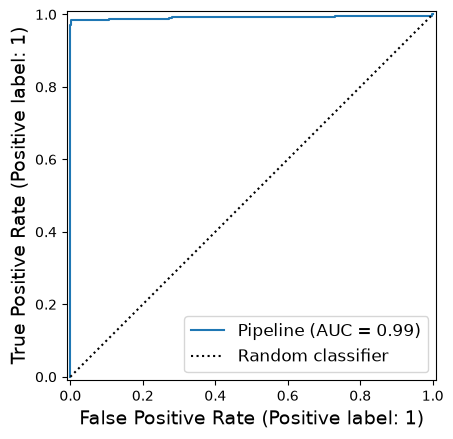

In [20]:
from sklearn.metrics import RocCurveDisplay

# Training Data
wine_test = test.drop("is_red", axis=1)
wine_test_labels = test['is_red'].copy()

# Your ROC curve display
RocCurveDisplay.from_estimator(log_reg, wine_test, wine_test_labels)
plt.plot([0, 1], [0, 1], "k:", label="Random classifier")
plt.legend()
plt.show()

The curve will display the AUROC value (shortened to AUC here). Write down your interpretation of the AUC in your own words in the context of the wine quality dataset.

**Your Answer:** The AUC on the test set is about 0.99. The AUC is the probability that the model ranks a randomly chosen red wine as more likely to be red than a randomly chosen white wine. So about 99% of the time, the model gives the red wine the higher probability. An AUC of 0.5 would be no better than random guessing and 1.0 would be a perfect separation, so our model separates red from white wines almost perfectly. In practice this means there is a threshold where we can catch nearly all red wines (high true positive rate) while mislabeling very few white wines as red (low false positive rate), which is why the curve hugs the top-left corner.

## Exercise 7 - Strength of Features in Determining Wine Type

Since our out-of-the-box logistic regression model is so good, let's look at which features have the highest $|\theta|$, as this can help indicate which feature(s) are the most influential in determining if a wine is red or white.

Print out the features from highest to lowest values of $|\theta|$, which will help us see which features are being heavily used in our model.

In [21]:
# Your solution to Exercise 7
theta = log_reg[-1].coef_[0]
feature_strengths = pd.DataFrame({
    "feature": wine_train.columns,
    "theta": theta,
    "|theta|": np.abs(theta),
}).sort_values("|theta|", ascending=False).reset_index(drop=True)

print("Intercept (bias):", log_reg[-1].intercept_[0])
feature_strengths

Intercept (bias): -4.167743093464915


,feature,theta,|theta|
0,density,3.463559,3.463559
1,residual_sugar,-3.419801,3.419801
2,total_sulfur_dioxide,-2.750840,2.750840
3,volatile_acidity,1.211128,1.211128
4,alcohol,1.118811,1.118811
5,chlorides,0.897397,0.897397
6,sulphates,0.719217,0.719217
7,free_sulfur_dioxide,0.715331,0.715331
8,citric_acid,-0.570021,0.570021
9,fixed_acidity,0.500109,0.500109


Based on your results, what are the top two most-used features used by your logistic regression model? Does a more positive value in those features correspond to the model having a higher change of labeling an instance as red or white wine?

**Your Answer**: The top two features are **density** ($\theta \approx +3.46$) and **residual sugar** ($\theta \approx -3.42$), followed by total sulfur dioxide ($\theta \approx -2.75$). Since the features are standardized, the magnitudes of $\theta$ are comparable. The target is `is_red = 1`, so a positive $\theta$ increases the log-odds of red:
* A higher **density** makes the model more likely to label a wine as **red**.
* A higher **residual sugar** makes the model more likely to label a wine as **white**. This matches the data: white wines in the training set average about 6.4 g/L of residual sugar versus about 2.5 g/L for reds.

One caveat: density and residual sugar are strongly correlated (dissolved sugar raises a wine's density), so the model uses them together. The large positive density weight is best read as "for the same sugar level, a denser wine is more likely red," not as a standalone effect.